# 1. Setup & Load Data

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

BASE_PATH = '/content/drive/MyDrive/stock_prediction-lstm-tft'
COLAB_PATH = f'{BASE_PATH}/03_colab'
MODEL_DATA_PATH = f'{BASE_PATH}/04_model/data'
LSTM_PATH = f'{BASE_PATH}/04_model/lstm'
RESULTS_PATH = f'{BASE_PATH}/05_results/lstm/figures'
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(LSTM_PATH, exist_ok=True)

# Load split data dan scalers
with open(f'{COLAB_PATH}/split_data.pkl', 'rb') as f:
    split_dict = pickle.load(f)

with open(f'{COLAB_PATH}/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

symbols = list(split_dict.keys())
print("Saham tersedia:", symbols)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saham tersedia: ['ASII.JK', 'BBCA.JK', 'ICBP.JK', 'TLKM.JK', 'UNVR.JK']


# 2. Arsitektur Model LSTM

Model LSTM dibangun dengan dua lapisan LSTM, dropout untuk mencegah overfitting,
dan satu lapisan Dense sebagai output prediksi harga close.

---



In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Cek input shape dari salah satu saham
sample = split_dict[symbols[0]]
input_shape = (sample['X_train'].shape[1], sample['X_train'].shape[2])
print("Input shape:", input_shape)

model = build_lstm_model(input_shape)
model.summary()

Input shape: (30, 8)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Pelatihan Model
Model dilatih per saham menggunakan early stopping untuk mencegah overfitting
dan model checkpoint untuk menyimpan bobot terbaik.

---



In [ ]:
EPOCHS = 100
BATCH_SIZE = 32

histories = {}

for symbol in symbols:
    print(f"\n{'='*50}")
    print(f"Training model untuk: {symbol}")
    print(f"{'='*50}")

    X_train = split_dict[symbol]['X_train']
    y_train = split_dict[symbol]['y_train']
    X_val   = split_dict[symbol]['X_val']
    y_val   = split_dict[symbol]['y_val']

    model = build_lstm_model(input_shape)

    sym = symbol.replace('.', '_')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint(f'{LSTM_PATH}/{sym}_lstm_best.keras',
                       monitor='val_loss', save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    histories[symbol] = history.history
    print(f"Training {symbol} selesai.")

# Simpan histories
with open(f'{LSTM_PATH}/lstm_history.pkl', 'wb') as f:
    pickle.dump(histories, f)

print("\nSemua model berhasil dilatih!")


Training model untuk: ASII.JK
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0528 - mae: 0.1628 - val_loss: 0.0027 - val_mae: 0.0432
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0082 - mae: 0.0715 - val_loss: 9.7483e-04 - val_mae: 0.0241
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0055 - mae: 0.0576 - val_loss: 0.0022 - val_mae: 0.0404
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0049 - mae: 0.0547 - val_loss: 8.0377e-04 - val_mae: 0.0230
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0050 - mae: 0.0547 - val_loss: 8.7430e-04 - val_mae: 0.0244
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0043 - mae: 0.0504 - val_loss: 0.0022 - val_mae: 0.0405
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0043 - mae: 0.0508 - val_loss: 7.0951e-04 - val_mae: 0.0214
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0040 - mae: 0.0493 - val_loss: 9.1478e-04 - val_mae: 0.0249
Epoch

# 4. Visualisasi Loss Curve
Visualisasi training dan validation loss untuk melihat proses konvergensi
masing-masing model.

---



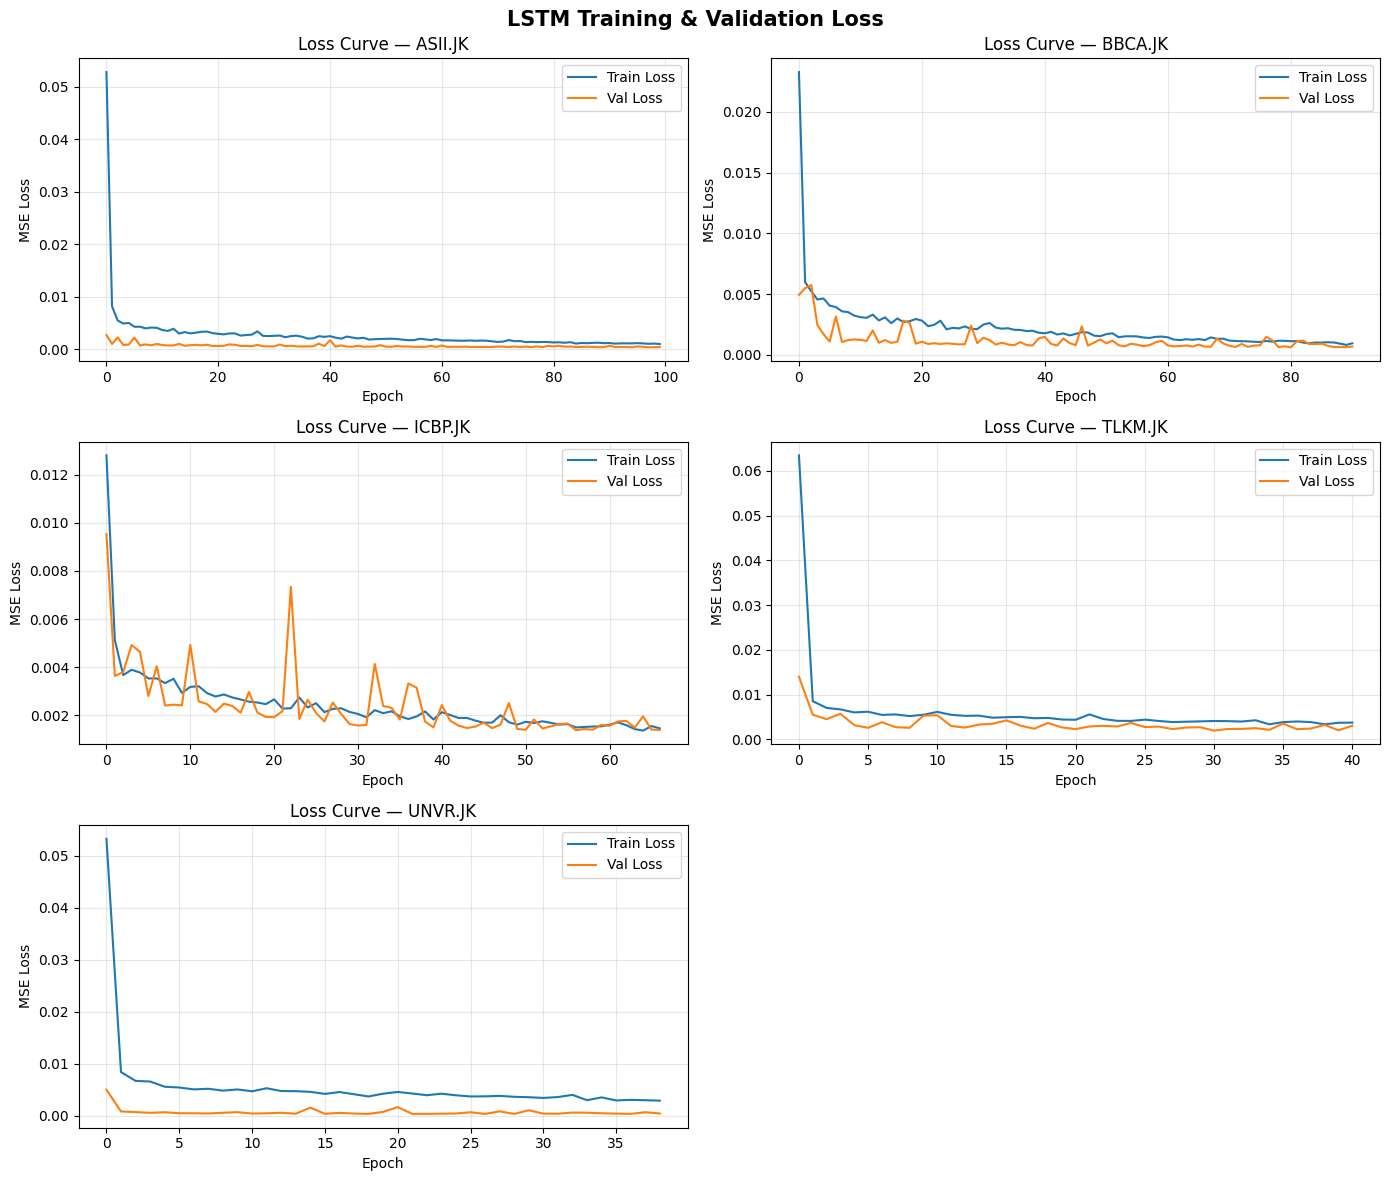

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, symbol in enumerate(symbols):
    axes[i].plot(histories[symbol]['loss'], label='Train Loss')
    axes[i].plot(histories[symbol]['val_loss'], label='Val Loss')
    axes[i].set_title(f'Loss Curve — {symbol}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Hapus subplot kosong
for j in range(len(symbols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('LSTM Training & Validation Loss', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Prediksi & Evaluasi
Melakukan prediksi pada data test dan mengevaluasi performa model
menggunakan metrik RMSE, MAE, dan MAPE.

---



In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = {}

for symbol in symbols:
    X_test = split_dict[symbol]['X_test']
    y_test = split_dict[symbol]['y_test']

    sym = symbol.replace('.', '_')
    model = tf.keras.models.load_model(f'{LSTM_PATH}/{sym}_lstm_best.keras')

    y_pred = model.predict(X_test).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[symbol] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2,
                       'y_test': y_test, 'y_pred': y_pred}

    print(f"{symbol} → RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")

with open(f'{LSTM_PATH}/lstm_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results tersimpan!")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
ASII.JK → RMSE: 0.0303 | MAE: 0.0224 | MAPE: 3.31% | R²: 0.9734
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
BBCA.JK → RMSE: 0.0313 | MAE: 0.0245 | MAPE: 3.66% | R²: 0.8080
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
ICBP.JK → RMSE: 0.0414 | MAE: 0.0315 | MAPE: 6.36% | R²: 0.9249
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
TLKM.JK → RMSE: 0.0609 | MAE: 0.0478 | MAPE: 11.97% | R²: 0.9250
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
UNVR.JK → RMSE: 0.0227 | MAE: 0.0149 | MAPE: 29.52% | R²: 0.9225
Results tersimpan!


# 6. Visualisasi Prediksi vs Aktual

---



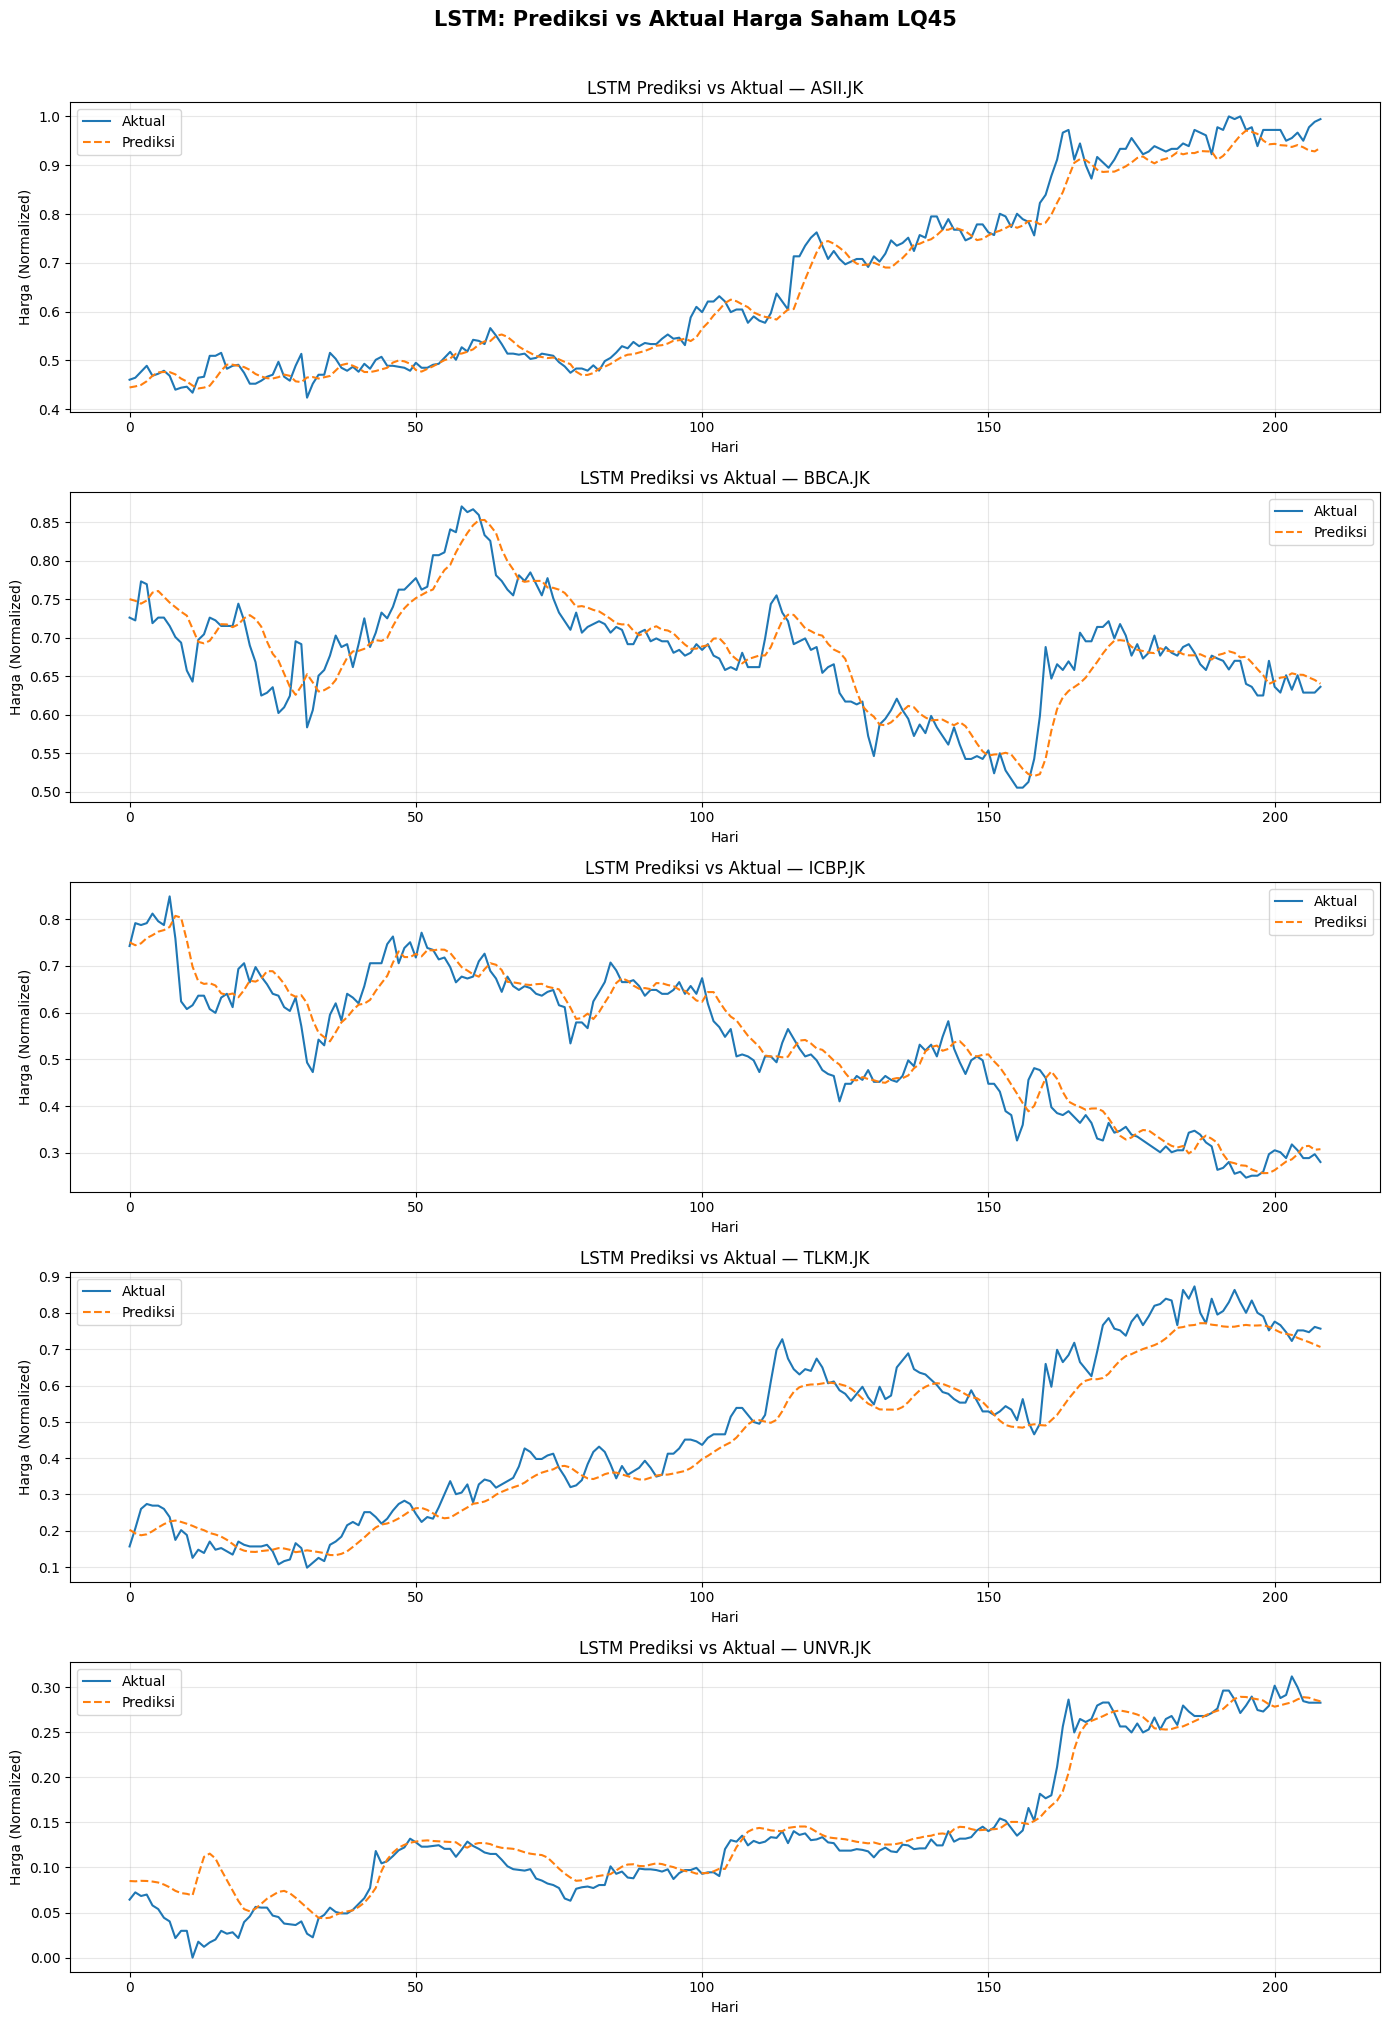

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for i, symbol in enumerate(symbols):
    y_test = results[symbol]['y_test']
    y_pred = results[symbol]['y_pred']

    axes[i].plot(y_test, label='Aktual', linewidth=1.5)
    axes[i].plot(y_pred, label='Prediksi', linewidth=1.5, linestyle='--')
    axes[i].set_title(f'LSTM Prediksi vs Aktual — {symbol}')
    axes[i].set_xlabel('Hari')
    axes[i].set_ylabel('Harga (Normalized)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('LSTM: Prediksi vs Aktual Harga Saham LQ45', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()